In [9]:
import pandas as pd

df = pd.read_csv(r"C:\wine.data", header=None)
X = df.iloc[:, 1:]

print(df.head())
print(X.shape)

   0      1     2     3     4    5     6     7     8     9     10    11    12  \
0   1  14.23  1.71  2.43  15.6  127  2.80  3.06  0.28  2.29  5.64  1.04  3.92   
1   1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
2   1  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
3   1  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
4   1  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   

     13  
0  1065  
1  1050  
2  1185  
3  1480  
4   735  
(178, 13)


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_raw = KMeans(n_clusters=3, random_state=42)
labels_raw = kmeans_raw.fit_predict(X)

score_raw = silhouette_score(X, labels_raw)
print("Before preprocessing:", score_raw)

Before preprocessing: 0.5595823478987215


In [11]:
# معلومات عامة
print(X.info())

# إحصائيات
print(X.describe())

# القيم المفقودة
print(X.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       178 non-null    float64
 1   2       178 non-null    float64
 2   3       178 non-null    float64
 3   4       178 non-null    float64
 4   5       178 non-null    int64  
 5   6       178 non-null    float64
 6   7       178 non-null    float64
 7   8       178 non-null    float64
 8   9       178 non-null    float64
 9   10      178 non-null    float64
 10  11      178 non-null    float64
 11  12      178 non-null    float64
 12  13      178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB
None
               1           2           3           4           5           6   \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean    13.000618    2.336348    2.366517   19.494944   99.741573    2.295112   
std      0.811827    1.117146    0.27434

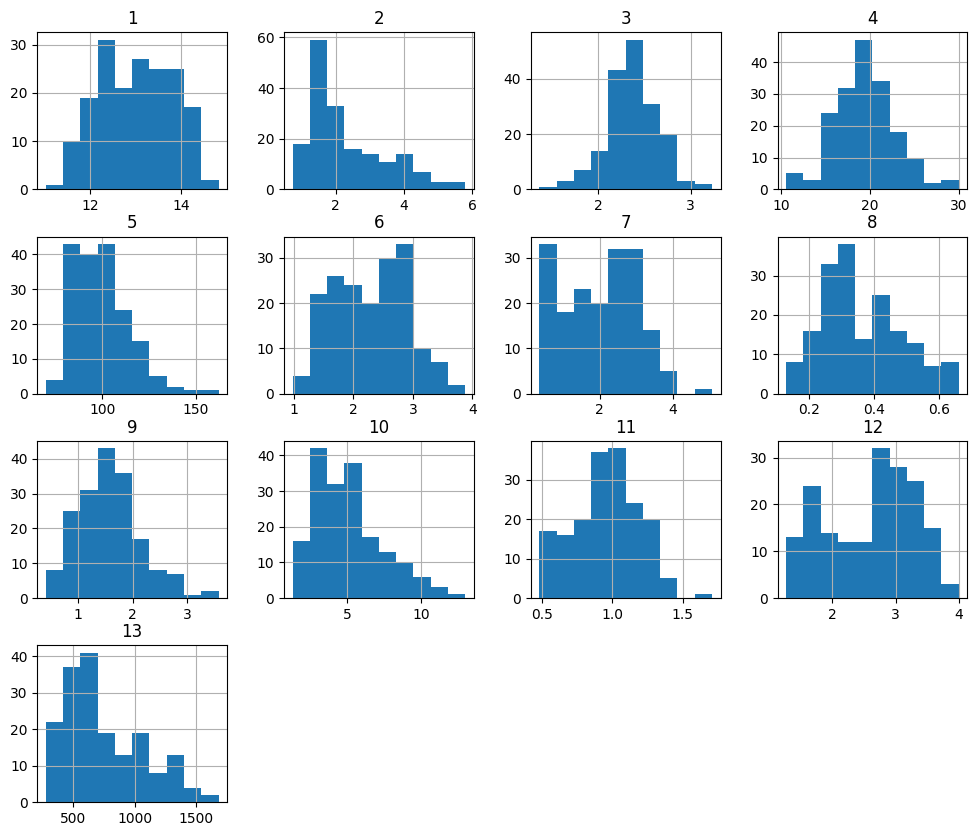

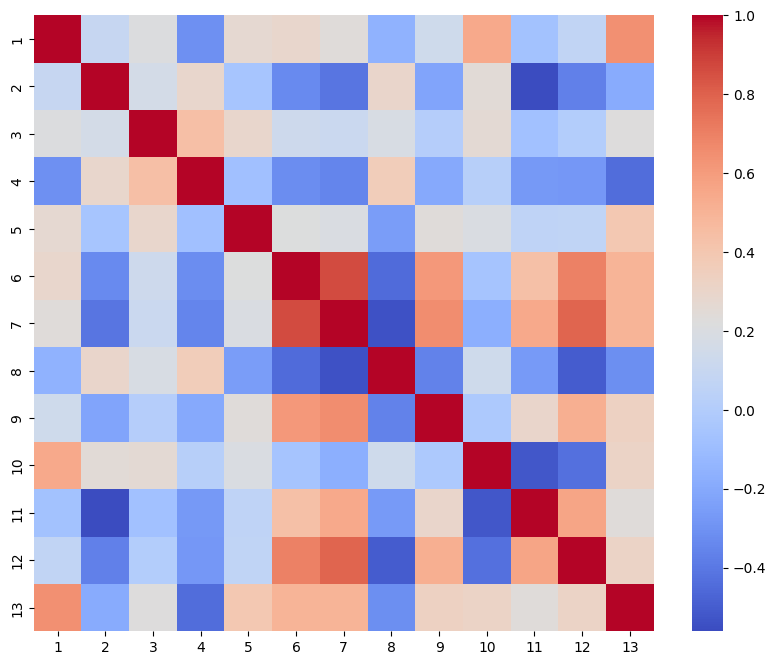

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
X.hist(figsize=(12,10))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_raw = KMeans(n_clusters=3, random_state=42)
labels_raw = kmeans_raw.fit_predict(X)

score_raw = silhouette_score(X, labels_raw)
print("Before preprocessing:", score_raw)

Before preprocessing: 0.5595823478987215


In [15]:
print(X_scaled.shape)

(178, 13)


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [17]:
print(X_pca.shape)

(178, 2)


In [18]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

score_pca = silhouette_score(X_pca, labels_pca)
print("After PCA:", score_pca)

After PCA: 0.5601697480957203


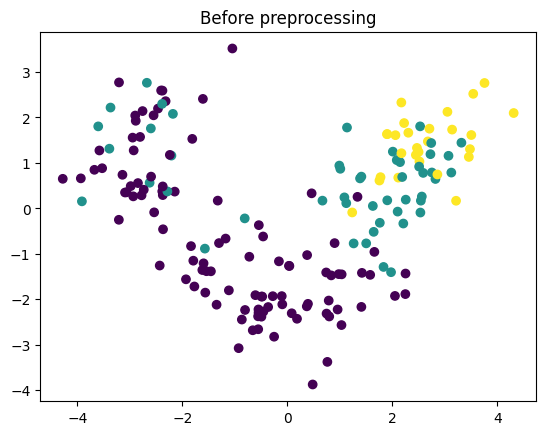

NameError: name 'labels_scaled' is not defined

In [19]:
import matplotlib.pyplot as plt

# قبل
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_raw)
plt.title("Before preprocessing")
plt.show()

# بعد scaling
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_scaled)
plt.title("After scaling")
plt.show()

# بعد PCA
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.title("After PCA")
plt.show()

In [20]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)

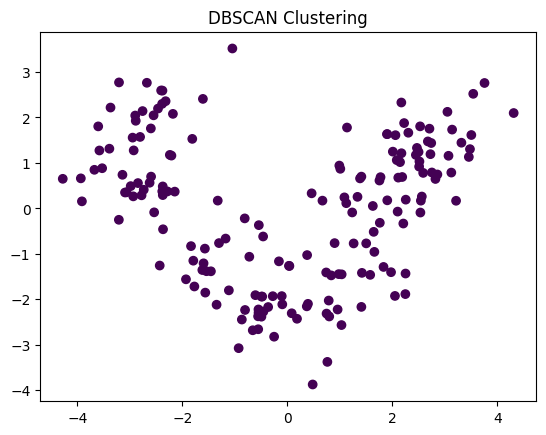

In [21]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN Clustering")
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import silhouette_score

# نحذف النقاط اللي قيمتها -1
mask = labels_db != -1

X_db = X_scaled[mask]
labels_db_clean = labels_db[mask]

# نحسب فقط إذا فيه أكثر من cluster
if len(set(labels_db_clean)) > 1:
    score_db = silhouette_score(X_db, labels_db_clean)
    print("DBSCAN Score:", score_db)
else:
    print("DBSCAN could not form valid clusters")

DBSCAN could not form valid clusters


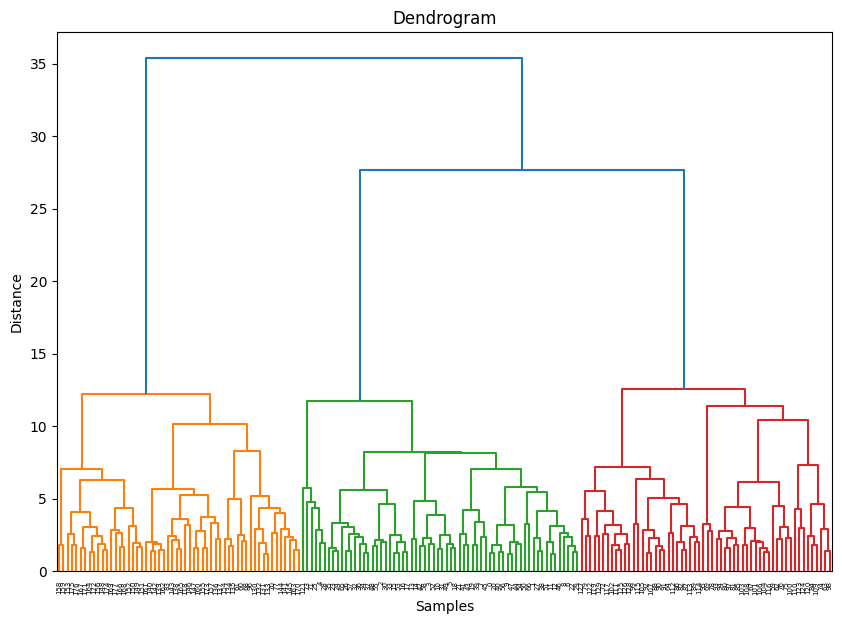

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [24]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)

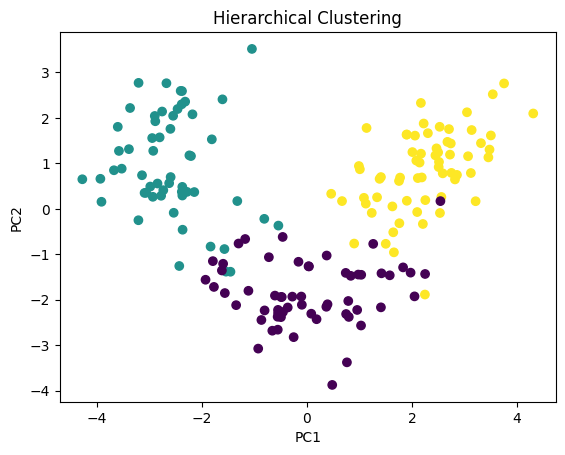

In [32]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_hc)
plt.title("Hierarchical Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("kmeans.png")
plt.show()

In [26]:
from sklearn.metrics import silhouette_score

score_hc = silhouette_score(X_scaled, labels_hc)
print("Hierarchical Score:", score_hc)

Hierarchical Score: 0.2774439826952265


In [27]:
import sys
print(sys.version)

3.10.0 | packaged by conda-forge | (default, Nov 10 2021, 13:20:59) [MSC v.1916 64 bit (AMD64)]


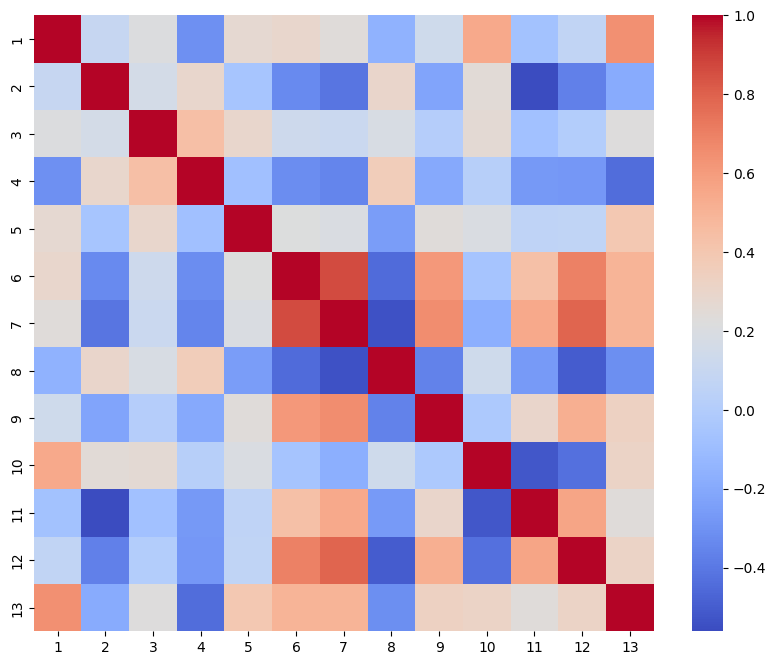

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.savefig("heatmap.png")
plt.show()

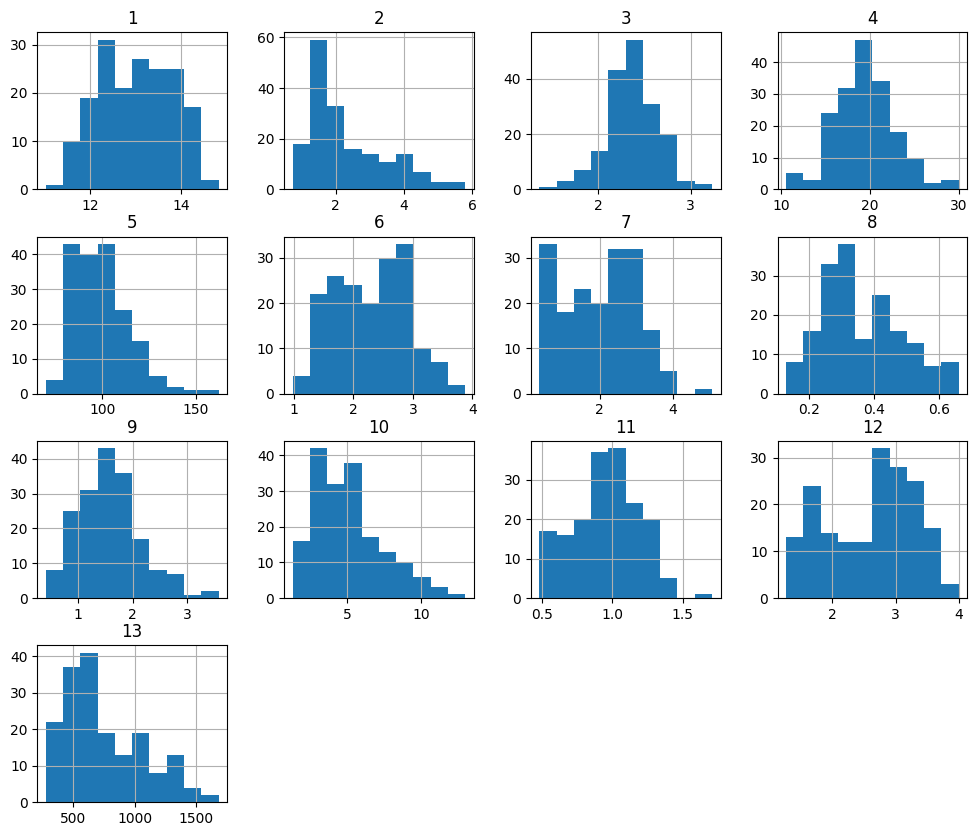

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
df = pd.read_csv(r"C:\wine.data", header=None)
X = df.iloc[:, 1:]

# رسم Histogram
X.hist(figsize=(12,10))
plt.savefig("histogram.png")
plt.show()

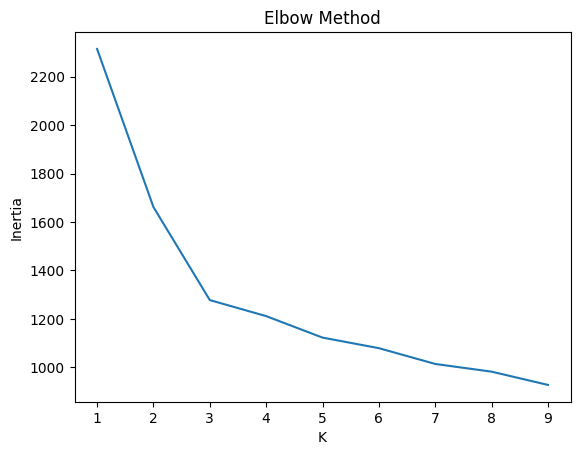

In [34]:
inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.savefig("elbow.png")
plt.show()